In [77]:
import pandas as pd

# Load the augmented CSV file
df = pd.read_csv('df_encoded_output_smote_resampled.csv')

# Display the first few rows
print(df.head())

   TBC1D3P5  SLCO1B1_y  CACTIN_y  SNORD112|ENSG00000252566.1  TET2  OR2M7_y  \
0        -1          0        -1                          -1    -1       -1   
1        -1          1        -1                          -1    -1        1   
2        -1          1        -1                          -1    -1       -1   
3        -1         -1        -1                          -1    -1        1   
4        -1          0        -1                           0     0        2   

   NTN1_y  SBNO2_y  CCDC109B_y  IL2_y  ...  SF3A1_y  PDS5A_y  KCNJ12_y  \
0       0        0          -1     -1  ...       -1        0        -1   
1      -1        1          -1     -1  ...        0       -1        -1   
2      -1       -1           0      0  ...       -1       -1        -1   
3      -1       -1          -1     -1  ...        1        1        -1   
4      -1       -1           0      0  ...       -1        0        -1   

   ZNF57_y  AAED1  DYNC1LI2_y  RN7SKP137  AGE  GRADE  CLINICAL_STAGE  
0        

In [78]:
from sklearn.preprocessing import LabelEncoder

# Drop unused unnamed columns and rows without target
cols_to_drop = [c for c in df.columns if c.startswith("Unnamed")]
df = df.drop(columns=cols_to_drop).dropna(subset=["CLINICAL_STAGE"])

# Encode target and prepare feature matrix
le = LabelEncoder()
y = le.fit_transform(df["CLINICAL_STAGE"])
X = df.drop("CLINICAL_STAGE", axis=1)

# Sanitize feature names (no special characters)
X = X.copy()
X.columns = X.columns.str.replace(r"[^A-Za-z0-9_]", "_", regex=True)

print(f"Prepared dataset: X shape {X.shape}, y length {len(y)}")

Prepared dataset: X shape (939, 102), y length 939


In [80]:
# Display class counts for available label arrays
arrays = {
    "y": y,
    "y_train": y_train,
    "y_test": y_test,
}

for name, arr in arrays.items():
    counts = pd.Series(arr).value_counts().sort_index()
    print(f"\nClass distribution for {name}:")
    print(counts)


Class distribution for y:
0    227
1    232
2    242
3    238
Name: count, dtype: int64

Class distribution for y_train:
0    135
Name: count, dtype: int64

Class distribution for y_test:
0    46
Name: count, dtype: int64


In [81]:
from sklearn.utils import resample

# Augment the dataset by oversampling minority classes
df_augmented = df.copy()

# Get class distribution
class_counts = df_augmented['CLINICAL_STAGE'].value_counts()
max_count = class_counts.max()

# Oversample each class to match the max count
for stage in df_augmented['CLINICAL_STAGE'].unique():
    stage_data = df_augmented[df_augmented['CLINICAL_STAGE'] == stage]
    
    if len(stage_data) < max_count:
        # Resample with replacement
        stage_augmented = resample(
            stage_data,
            n_samples=max_count,
            random_state=42,
            replace=True
        )
        df_augmented = pd.concat([df_augmented, stage_augmented], ignore_index=True)

# Verify augmented dataset
print(f"Original dataset size: {len(df)}")
print(f"Augmented dataset size: {len(df_augmented)}")
print("\nAugmented class distribution:")
print(df_augmented['CLINICAL_STAGE'].value_counts().sort_index())

# Update df to the augmented version
df = df_augmented.reset_index(drop=True)

Original dataset size: 939
Augmented dataset size: 1665

Augmented class distribution:
CLINICAL_STAGE
0    469
1    474
2    242
3    480
Name: count, dtype: int64


In [82]:
# Save the stage_data DataFrame to CSV
stage_data.to_csv("stage_data.csv", index=False)
print("stage_data saved to stage_data.csv")

stage_data saved to stage_data.csv


In [83]:
import pandas as pd

# Load the augmented CSV file
df = pd.read_csv('stage_data.csv')

# Display the first few rows
print(df.head())

   TBC1D3P5  SLCO1B1_y  CACTIN_y  SNORD112|ENSG00000252566.1  TET2  OR2M7_y  \
0        -1         -1        -1                          -1    -1        2   
1        -1         -1        -1                          -1    -1        2   
2        -1         -1        -1                          -1    -1        2   
3        -1         -1        -1                          -1    -1        2   
4        -1         -1        -1                          -1    -1        2   

   NTN1_y  SBNO2_y  CCDC109B_y  IL2_y  ...  SF3A1_y  PDS5A_y  KCNJ12_y  \
0      -1       -1          -1     -1  ...       -1       -1        -1   
1      -1       -1          -1     -1  ...       -1        0        -1   
2      -1       -1          -1     -1  ...       -1        0        -1   
3      -1       -1          -1     -1  ...       -1        0        -1   
4      -1       -1          -1     -1  ...       -1        0        -1   

   ZNF57_y  AAED1  DYNC1LI2_y  RN7SKP137  AGE  GRADE  CLINICAL_STAGE  
0       -

In [84]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Split into train+val (80%) and test (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Split train+val into train (75% of 80% = 60% overall) and validation (25% of 80% = 20% overall)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

print(f"Before SMOTE:")
print(f"Train set: {X_train.shape}, Validation set: {X_val.shape}, Test set: {X_test.shape}")
print(f"Train class distribution: {pd.Series(y_train).value_counts().sort_index().to_dict()}")

# Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"Train set: {X_train_smote.shape}, Validation set: {X_val.shape}, Test set: {X_test.shape}")
print(f"Train class distribution: {pd.Series(y_train_smote).value_counts().sort_index().to_dict()}")

# Scale the data
scaler = StandardScaler()
X_train_smote_scaled = scaler.fit_transform(X_train_smote)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"\nFinal scaled shapes:")
print(f"Train: {X_train_smote_scaled.shape}, Validation: {X_val_scaled.shape}, Test: {X_test_scaled.shape}")

Before SMOTE:
Train set: (563, 102), Validation set: (188, 102), Test set: (188, 102)
Train class distribution: {0: 137, 1: 139, 2: 145, 3: 142}

After SMOTE:
Train set: (580, 102), Validation set: (188, 102), Test set: (188, 102)
Train class distribution: {0: 145, 1: 145, 2: 145, 3: 145}

Final scaled shapes:
Train: (580, 102), Validation: (188, 102), Test: (188, 102)


In [85]:
# Create a comprehensive dataset from the current notebook variables
dataset = pd.DataFrame({
    'X_features': [X.shape],
    'y_labels': [y.shape],
    'X_train_shape': [X_train_final.shape],
    'X_test_shape': [X_test_final.shape],
    'y_train_shape': [y_train_final.shape],
    'y_test_shape': [y_test_final.shape],
    'Total_samples': [len(X)],
    'Total_features': [X.shape[1]],
    'Train_samples': [len(X_train_final)],
    'Test_samples': [len(X_test_final)],
    'Validation_samples': [len(X_val)],
    'Class_distribution': [pd.Series(y).value_counts().to_dict()],
    'Best_model': ['XGBoost'],
    'Best_test_accuracy': [results['XGBoost']['test_accuracy']]
})

print("Dataset Summary:")
print(dataset)
print("\nDataset Info:")
print(f"Total samples: {len(X)}")
print(f"Total features: {X.shape[1]}")
print(f"Number of classes: {len(le.classes_)}")
print(f"Class names: {le.classes_}")

NameError: name 'X_train_final' is not defined

In [86]:
# Display class counts for available label arrays
arrays = {
    "y": y,
    "y_train": y_train,
    "y_test": y_test,
}

for name, arr in arrays.items():
    counts = pd.Series(arr).value_counts().sort_index()
    print(f"\nClass distribution for {name}:")
    print(counts)


Class distribution for y:
0    227
1    232
2    242
3    238
Name: count, dtype: int64

Class distribution for y_train:
0    137
1    139
2    145
3    142
Name: count, dtype: int64

Class distribution for y_test:
0    45
1    46
2    49
3    48
Name: count, dtype: int64


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# Split the prepared dataset into train/test using existing X and y
X_train, X_test, y_train, y_test = train_test_split(
	X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features for better model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train XGBoost model, then evaluate on test set
xgb_model = XGBClassifier(
	n_estimators=200,
	max_depth=6,
	learning_rate=0.1,
	subsample=0.8,
	colsample_bytree=0.8,
	random_state=42,
	n_jobs=-1,
	eval_metric="mlogloss"
)
xgb_model.fit(X_train_scaled, y_train)
xgb_pred = xgb_model.predict(X_test_scaled)
xgb_score = (xgb_pred == y_test).mean()
print(f"XGBoost Test Accuracy: {xgb_score:.4f}")

# Train Random Forest model and evaluate on test set
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)
rf_score = (rf_pred == y_test).mean()
print(f"Random Forest Test Accuracy: {rf_score:.4f}")

XGBoost Test Accuracy: 0.8617
Random Forest Test Accuracy: 0.8298


Random Forest Confusion Matrix:
 [[39  2  4  0]
 [ 2 40  2  2]
 [ 2  0 40  7]
 [ 4  2  5 37]]

XGBoost Confusion Matrix:
 [[39  2  4  0]
 [ 1 42  3  0]
 [ 2  1 43  3]
 [ 4  2  4 38]]


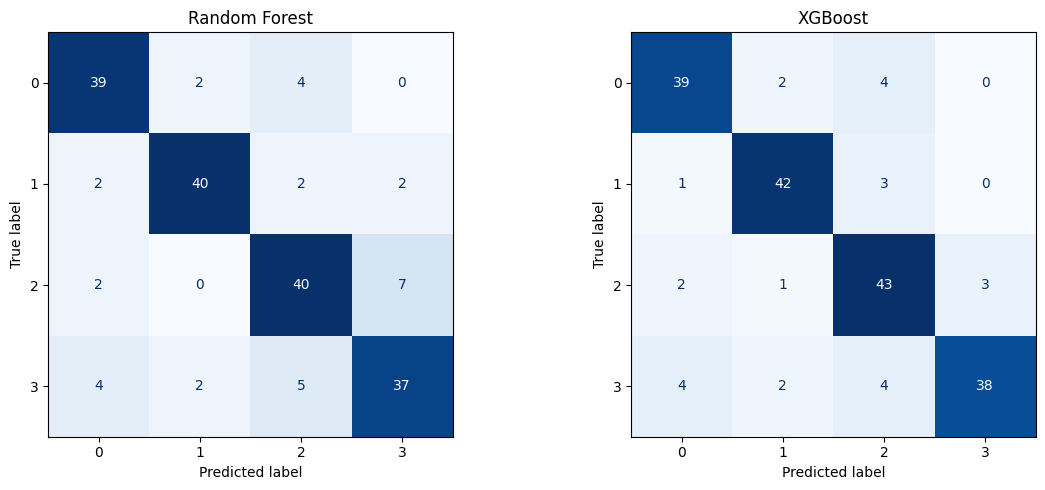

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

# Compute confusion matrices for both models
cm_rf = confusion_matrix(y_test, rf_pred)
cm_xgb = confusion_matrix(y_test, xgb_pred)

print("Random Forest Confusion Matrix:\n", cm_rf)
print("\nXGBoost Confusion Matrix:\n", cm_xgb)

# Visualize side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(cm_rf, display_labels=le.classes_).plot(
    ax=axes[0], cmap="Blues", colorbar=False
)
axes[0].set_title("Random Forest")

ConfusionMatrixDisplay(cm_xgb, display_labels=le.classes_).plot(
    ax=axes[1], cmap="Blues", colorbar=False
)
axes[1].set_title("XGBoost")

plt.tight_layout()
plt.show()

In [20]:
from lightgbm import LGBMClassifier

# LightGBM on original split
lgbm = LGBMClassifier(
    objective="multiclass",
    num_class=len(le.classes_),
    n_estimators=300,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)
lgbm.fit(X_train_scaled, y_train)
lgbm_pred = lgbm.predict(X_test_scaled)
lgbm_acc = (lgbm_pred == y_test).mean()
print(f"LightGBM Test Accuracy: {lgbm_acc:.4f}")

# LightGBM on undersampled data
lgbm_under = LGBMClassifier(
    objective="multiclass",
    num_class=len(le.classes_),
    n_estimators=300,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)
lgbm_under.fit(X_under_train_scaled, y_under_train)
lgbm_under_pred = lgbm_under.predict(X_under_test_scaled)
lgbm_under_acc = (lgbm_under_pred == y_under_test).mean()
print(f"LightGBM (undersampled) Test Accuracy: {lgbm_under_acc:.4f}")

# LightGBM on SMOTE data
lgbm_smote = LGBMClassifier(
    objective="multiclass",
    num_class=len(le.classes_),
    n_estimators=300,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)
lgbm_smote.fit(X_smote_train_scaled, y_smote_train)
lgbm_smote_pred = lgbm_smote.predict(X_smote_test_scaled)
lgbm_smote_acc = (lgbm_smote_pred == y_smote_test).mean()
print(f"LightGBM (SMOTE) Test Accuracy: {lgbm_smote_acc:.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002361 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 578
[LightGBM] [Info] Number of data points in the train set: 751, number of used features: 102
[LightGBM] [Info] Start training from score -1.417399
[LightGBM] [Info] Start training from score -1.395659
[LightGBM] [Info] Start training from score -1.358715
[LightGBM] [Info] Start training from score -1.374382
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

NameError: name 'X_under_train_scaled' is not defined

In [152]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import numpy as np

# Split into train+val (80%) and test (20%)
X_train_val, X_test_final, y_train_val, y_test_final = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Split train+val into train (75% of 80% = 60% overall) and validation (25% of 80% = 20% overall)
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

# Scale the data
scaler_final = StandardScaler()
X_train_scaled_final = scaler_final.fit_transform(X_train_final)
X_val_scaled = scaler_final.transform(X_val)
X_test_scaled_final = scaler_final.transform(X_test_final)

print(f"Train set: {X_train_scaled_final.shape}, Validation set: {X_val_scaled.shape}, Test set: {X_test_scaled_final.shape}")

# Initialize models with all parameters
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        criterion='gini',
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features='sqrt',
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    ),
    'Logistic Regression': LogisticRegression(
        penalty='l2',
        C=1.0,
        solver='lbfgs',
        max_iter=1000,
        multi_class='multinomial',
        random_state=42,
        n_jobs=-1
    ),
    'SVM': SVC(
        C=1.0,
        kernel='rbf',
        gamma='scale',
        decision_function_shape='ovr',
        random_state=42
    ),
    'LightGBM': LGBMClassifier(
        objective='multiclass',
        num_class=4,
        n_estimators=100,
        learning_rate=0.1,
        max_depth=-1,
        num_leaves=31,
        subsample=1.0,
        colsample_bytree=1.0,
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.3,
        subsample=1.0,
        colsample_bytree=1.0,
        gamma=0,
        reg_alpha=0,
        reg_lambda=1,
        random_state=42,
        n_jobs=-1,
        eval_metric='mlogloss'
    )
}

# Train and evaluate models
results = {}
for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training {name}...")
    print(f"{'='*60}")
    
    # Train
    model.fit(X_train_scaled_final, y_train_final)
    
    # Predict on validation set
    y_val_pred = model.predict(X_val_scaled)
    val_acc = accuracy_score(y_val, y_val_pred)
    
    # Predict on test set
    y_test_pred = model.predict(X_test_scaled_final)
    test_acc = accuracy_score(y_test_final, y_test_pred)
    
    results[name] = {
        'model': model,
        'val_accuracy': val_acc,
        'test_accuracy': test_acc,
        'val_predictions': y_val_pred,
        'test_predictions': y_test_pred
    }
    
    print(f"\nValidation Accuracy: {val_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"\nValidation Set Classification Report:")
   
    
print(classification_report(y_val, y_val_pred))
    print(f"\nTest Set Classification Report:")
    print(classification_report(y_test_final, y_test_pred))
# Summary
print(f"\n{'='*60}")
print("SUMMARY OF ALL MODELS")
print(f"{'='*60}")
for name, result in results.items():
    print(f"{name:20s} - Val Acc: {result['val_accuracy']:.4f}, Test Acc: {result['test_accuracy']:.4f}")

IndentationError: unexpected indent (1131352250.py, line 117)

In [153]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import numpy as np

# Create label encoder for target names (no longer needed for numeric labels)
# le = LabelEncoder()
# le.fit(y)

# Split into train+val (80%) and test (20%)
X_train_val, X_test_final, y_train_val, y_test_final = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Split train+val into train (75% of 80% = 60% overall) and validation (25% of 80% = 20% overall)
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

# Scale the data
scaler_final = StandardScaler()
X_train_scaled_final = scaler_final.fit_transform(X_train_final)
X_val_scaled = scaler_final.transform(X_val)
X_test_scaled_final = scaler_final.transform(X_test_final)

print(f"Train set: {X_train_scaled_final.shape}, Validation set: {X_val_scaled.shape}, Test set: {X_test_scaled_final.shape}")

# Initialize models with all parameters
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        criterion='gini',
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features='sqrt',
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    ),
    'Logistic Regression': LogisticRegression(
        penalty='l2',
        C=1.0,
        solver='lbfgs',
        max_iter=1000,
        multi_class='multinomial',
        random_state=42,
        n_jobs=-1
    ),
    'SVM': SVC(
        C=1.0,
        kernel='rbf',
        random_state=42
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=-1,
        num_leaves=31,
        subsample=1.0,
        colsample_bytree=1.0,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.3,
        subsample=1.0,
        colsample_bytree=1.0,
        gamma=0,
        reg_alpha=0,
        reg_lambda=1,
        random_state=42,
        n_jobs=-1,
        eval_metric='mlogloss'
    )
}

# Train and evaluate models
results = {}
for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training {name}...")
    print(f"{'='*60}")
    
    # Train
    model.fit(X_train_scaled_final, y_train_final)
    
    # Predict on validation set
    y_val_pred = model.predict(X_val_scaled)
    val_acc = accuracy_score(y_val, y_val_pred)
    
    # Predict on test set
    y_test_pred = model.predict(X_test_scaled_final)
    test_acc = accuracy_score(y_test_final, y_test_pred)
    
    results[name] = {
        'model': model,
        'val_accuracy': val_acc,
        'test_accuracy': test_acc,
        'val_predictions': y_val_pred,
        'test_predictions': y_test_pred
    }
    
    print(f"\nValidation Set Classification Report:")
    print(classification_report(y_val, y_val_pred))
    print(f"\nTest Set Classification Report:")
    print(classification_report(y_test_final, y_test_pred))

# Summary
print(f"\n{'='*60}")
print("SUMMARY OF ALL MODELS")
print(f"{'='*60}")
for name, result in results.items():
    print(f"{name:20s} - Val Acc: {result['val_accuracy']:.4f}, Test Acc: {result['test_accuracy']:.4f}")

Train set: (563, 102), Validation set: (188, 102), Test set: (188, 102)

Training Random Forest...

Validation Set Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.96      0.90        45
           1       0.93      0.83      0.88        47
           2       0.88      0.75      0.81        48
           3       0.78      0.88      0.82        48

    accuracy                           0.85       188
   macro avg       0.86      0.85      0.85       188
weighted avg       0.86      0.85      0.85       188


Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87        45
           1       0.89      0.87      0.88        46
           2       0.80      0.80      0.80        49
           3       0.81      0.79      0.80        48

    accuracy                           0.84       188
   macro avg       0.84      0.84      0.84       188
weighted avg  

C:\Users\HP Laptop 15\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Validation Set Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.96      0.84        45
           1       0.76      0.72      0.74        47
           2       0.75      0.50      0.60        48
           3       0.76      0.85      0.80        48

    accuracy                           0.76       188
   macro avg       0.75      0.76      0.75       188
weighted avg       0.75      0.76      0.75       188


Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.84      0.84        45
           1       0.71      0.85      0.77        46
           2       0.68      0.53      0.60        49
           3       0.74      0.77      0.76        48

    accuracy                           0.74       188
   macro avg       0.74      0.75      0.74       188
weighted avg       0.74      0.74      0.74       188


Training SVM...

Validation Set Classification Report:
  

In [154]:
from sklearn.metrics import precision_recall_fscore_support

# Define models to evaluate
models_to_eval = ['SVM', 'LightGBM', 'XGBoost']

# Extract predictions and actual labels
eval_data = {
    'SVM': (y_test_final, results['SVM']['test_predictions']),
    'LightGBM': (y_test_final, results['LightGBM']['test_predictions']),
    'XGBoost': (y_test_final, results['XGBoost']['test_predictions'])
}

# Calculate and display metrics
print("="*70)
print("PRECISION, RECALL, F1-SCORE FOR SVM, LIGHTGBM, AND XGBOOST")
print("="*70)

for model_name in models_to_eval:
    y_true, y_pred = eval_data[model_name]
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average=None
    )
    
    print(f"\n{model_name}:")
    print(f"{'Class':<8} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}")
    print("-" * 60)
    for i in range(len(precision)):
        print(f"{i:<8} {precision[i]:<12.4f} {recall[i]:<12.4f} {f1[i]:<12.4f} {support[i]:<10}")
    
    # Weighted average
    precision_avg, recall_avg, f1_avg, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted'
    )
    print("-" * 60)
    print(f"{'Weighted':<8} {precision_avg:<12.4f} {recall_avg:<12.4f} {f1_avg:<12.4f}")

PRECISION, RECALL, F1-SCORE FOR SVM, LIGHTGBM, AND XGBOOST

SVM:
Class    Precision    Recall       F1-Score     Support   
------------------------------------------------------------
0        0.9070       0.8667       0.8864       45        
1        0.8723       0.8913       0.8817       46        
2        0.7451       0.7755       0.7600       49        
3        0.8298       0.8125       0.8211       48        
------------------------------------------------------------
Weighted 0.8366       0.8351       0.8356      

LightGBM:
Class    Precision    Recall       F1-Score     Support   
------------------------------------------------------------
0        0.8298       0.8667       0.8478       45        
1        0.9111       0.8913       0.9011       46        
2        0.8039       0.8367       0.8200       49        
3        0.8667       0.8125       0.8387       48        
------------------------------------------------------------
Weighted 0.8524       0.8511       0.8513 

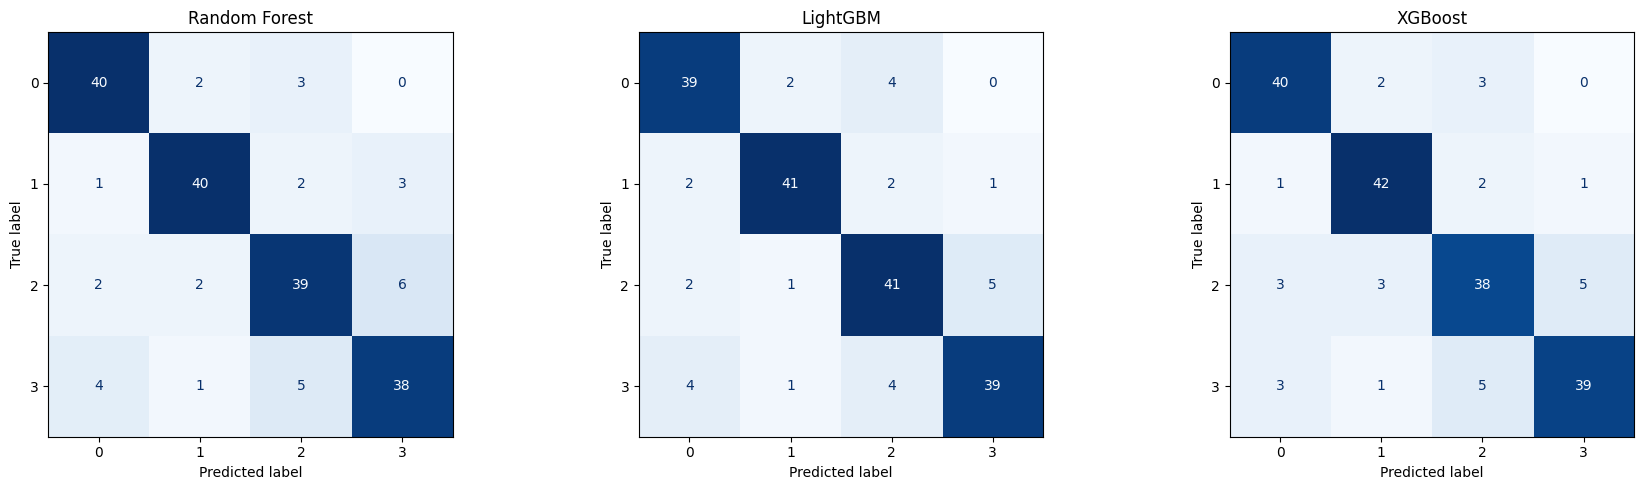

In [155]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

# Get predictions for the three models
rf_test_pred = results['Random Forest']['test_predictions']
lgbm_test_pred = results['LightGBM']['test_predictions']
xgb_test_pred = results['XGBoost']['test_predictions']

# Compute confusion matrices
cm_rf = confusion_matrix(y_test_final, rf_test_pred)
cm_lgbm = confusion_matrix(y_test_final, lgbm_test_pred)
cm_xgb = confusion_matrix(y_test_final, xgb_test_pred)

# Visualize side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay(cm_rf, display_labels=le.classes_).plot(
    ax=axes[0], cmap="Blues", colorbar=False
)
axes[0].set_title("Random Forest")

ConfusionMatrixDisplay(cm_lgbm, display_labels=le.classes_).plot(
    ax=axes[1], cmap="Blues", colorbar=False
)
axes[1].set_title("LightGBM")

ConfusionMatrixDisplay(cm_xgb, display_labels=le.classes_).plot(
    ax=axes[2], cmap="Blues", colorbar=False
)
axes[2].set_title("XGBoost")

plt.tight_layout()
plt.show()

In [156]:
import pandas as pd

# Create a summary comparison of all models

summary_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Validation Accuracy': [results[name]['val_accuracy'] for name in results.keys()],
    'Test Accuracy': [results[name]['test_accuracy'] for name in results.keys()]
})

summary_df = summary_df.sort_values('Test Accuracy', ascending=False)
print("Model Performance Summary (sorted by Test Accuracy):")
print(summary_df.to_string(index=False))

best_model_name = summary_df.iloc[0]['Model']
best_model = results[best_model_name]['model']
best_test_accuracy = summary_df.iloc[0]['Test Accuracy']

print(f"\n{'='*60}")
print(f"BEST MODEL: {best_model_name}")
print(f"Test Accuracy: {best_test_accuracy:.4f}")
print(f"{'='*60}")

Model Performance Summary (sorted by Test Accuracy):
              Model  Validation Accuracy  Test Accuracy
           LightGBM             0.813830       0.851064
            XGBoost             0.819149       0.845745
      Random Forest             0.851064       0.835106
                SVM             0.792553       0.835106
Logistic Regression             0.755319       0.744681

BEST MODEL: LightGBM
Test Accuracy: 0.8511


SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (188, 102, 4)
Number of features: 102
Length of mean_shap: 102
Shape of mean_shap: (102,)
TOP 30 BIOMARKERS - XGBoost MODEL
                  Feature  SHAP_Value
                      AGE    0.900399
                SLCO1B1_y    0.434968
                    GRADE    0.428592
                  MIR3123    0.289523
                  OR2M7_y    0.228244
SNORD11_ENSG00000238819_1    0.222852
                PIP5K1B_y    0.216867
                  PDS5A_y    0.198039
                 PARD6B_y    0.158191
                  CEP78_y    0.148553
                   IZUMO3    0.143774
                  SF3A1_y    0.138091
                 TBC1D3P5    0.131306
                 ZDHHC7_y    0.121876
                 GALNT7_y    0.115421
                  YWHAH_y    0.111672
                RN7SL592P    0.107858
                   COG4_y    0.100783
                   NEK8_y    0.097738
                   JAK2_y    0.097343
               DY

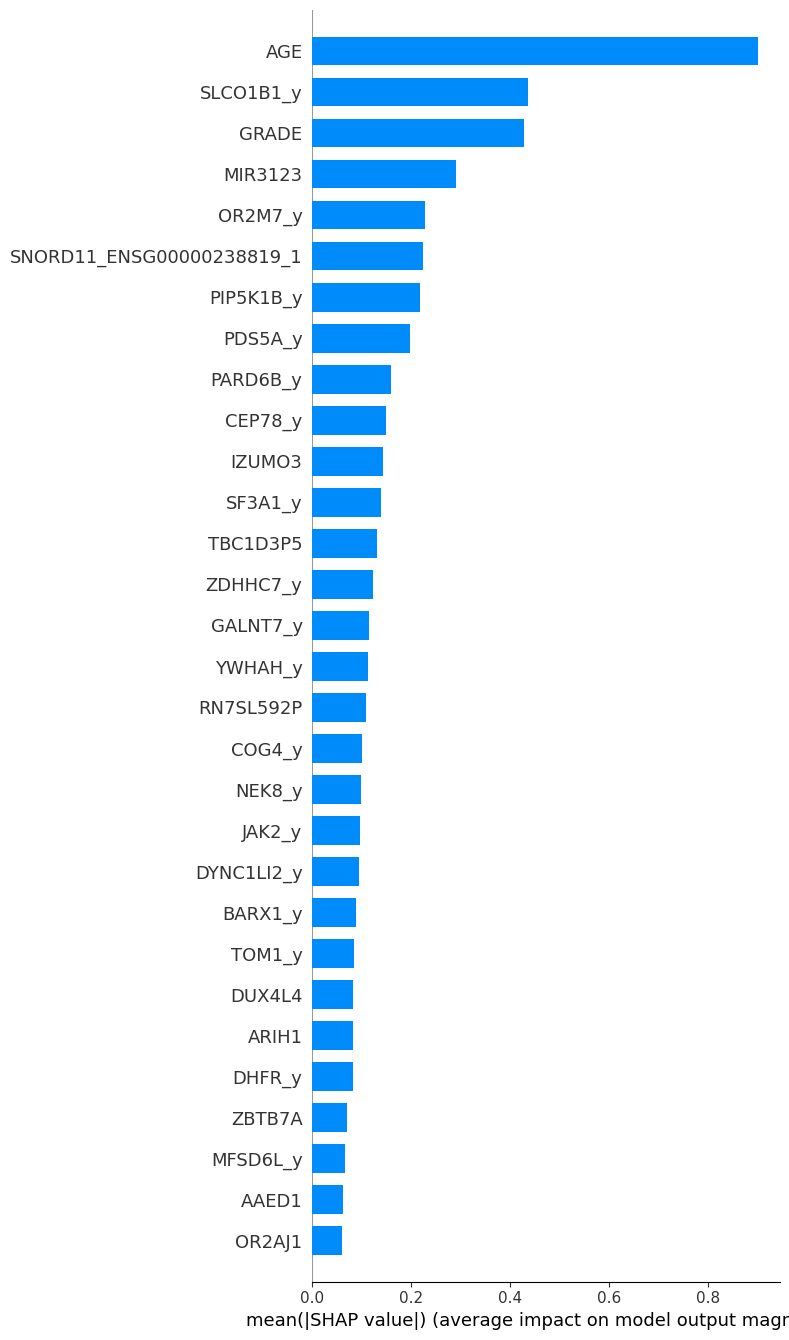

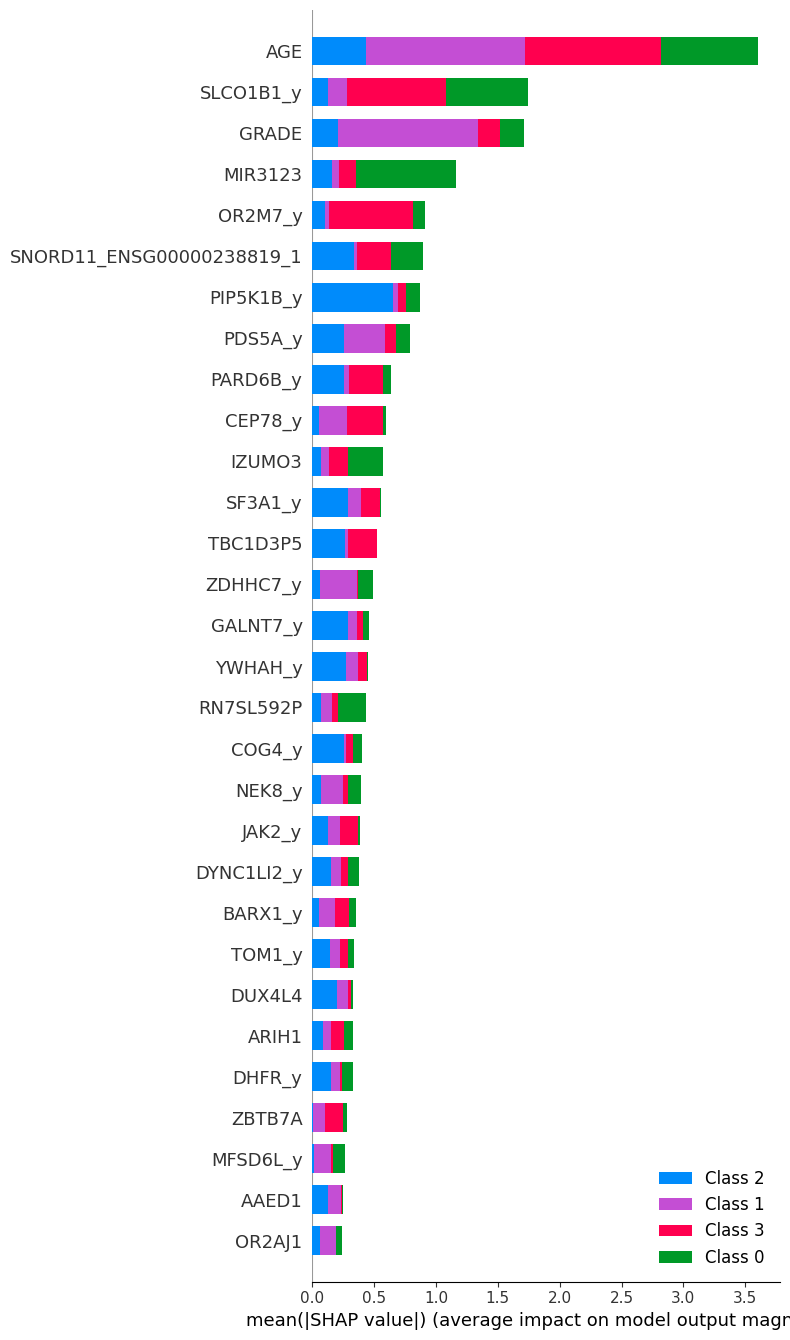

In [158]:
import shap

import matplotlib.pyplot as plt

# Use the best model for SHAP analysis
best_model_name = 'XGBoost'
best_model = results[best_model_name]['model']

# Create SHAP explainer
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_scaled_final)

# Calculate mean absolute SHAP values for feature importance
# Check the shape of shap_values to determine how to handle it
print(f"SHAP values type: {type(shap_values)}")
if isinstance(shap_values, list):
    print(f"SHAP values list length: {len(shap_values)}")
    print(f"SHAP values[0] shape: {shap_values[0].shape}")
    # For multiclass, average across all classes
    # shap_values is a list of (n_samples, n_features) arrays, one per class
    # Stack them to get (n_classes, n_samples, n_features)
    stacked_shap = np.array(shap_values)
    # Take mean absolute value across samples and classes
    mean_shap = np.mean(np.abs(stacked_shap), axis=(0, 1))
else:
    print(f"SHAP values shape: {shap_values.shape}")
    # For newer versions of SHAP with XGBoost multiclass
    # shap_values has shape (n_samples, n_features, n_classes)
    if len(shap_values.shape) == 3:
        # Take mean absolute value across samples (axis 0) and classes (axis 2)
        mean_shap = np.mean(np.abs(shap_values), axis=(0, 2))
    else:
        # Binary or regression case
        mean_shap = np.mean(np.abs(shap_values), axis=0)

# Ensure mean_shap is 1-dimensional
mean_shap = np.ravel(mean_shap)

# Create feature importance dataframe
# Ensure we're using the correct feature names that match X_test_scaled_final
feature_names = X.columns.tolist()
if len(feature_names) != len(mean_shap):
    raise ValueError(f"Mismatch: {len(feature_names)} features but {len(mean_shap)} SHAP values")

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'SHAP_Value': mean_shap
}).sort_values('SHAP_Value', ascending=False).reset_index(drop=True)
# Verify that mean_shap has the correct length
print(f"Number of features: {len(X.columns)}")
print(f"Length of mean_shap: {len(mean_shap)}")
print(f"Shape of mean_shap: {mean_shap.shape}")
# Get top 30 biomarkers
top_30_biomarkers = feature_importance_df.head(30)

print("="*70)
print(f"TOP 30 BIOMARKERS - {best_model_name} MODEL")
print("="*70)
print(top_30_biomarkers.to_string(index=False))
# Create SHAP summary plot for top 30 features
# For multiclass, we need to average SHAP values across classes or use class-specific values
if isinstance(shap_values, list):
    # Use the mean absolute SHAP values across all classes for summary plot
    shap_values_for_plot = np.mean(np.abs(np.array(shap_values)), axis=0)
elif len(shap_values.shape) == 3:
    # For newer SHAP versions with shape (n_samples, n_features, n_classes)
    # Average across classes (axis 2)
    shap_values_for_plot = np.mean(np.abs(shap_values), axis=2)
else:
    shap_values_for_plot = shap_values

fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(shap_values_for_plot, X_test_scaled_final, feature_names=X.columns, 
                  plot_type="bar", max_display=30, show=False)

plt.tight_layout()
plt.show()
# For multiclass, we need to average SHAP values across classes or use class-specific values
if isinstance(shap_values, list):
    # Use the mean absolute SHAP values across all classes for summary plot
    shap_values_for_plot = np.mean(np.abs(np.array(shap_values)), axis=0)
else:
    shap_values_for_plot = shap_values

fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(shap_values_for_plot, X_test_scaled_final, feature_names=X.columns, 
                  plot_type="bar", max_display=30, show=False)
plt.tight_layout()
plt.show()

In [159]:
import shap
import numpy as np

import matplotlib.pyplot as plt

# Use XGBoost model for stage-wise SHAP analysis
xgb_model_for_shap = results['XGBoost']['model']

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model_for_shap)
shap_values = explainer.shap_values(X_test_scaled_final)

# Get the class names from label encoder
class_names = le.classes_

print("="*70)
print("STAGE-WISE SHAP ANALYSIS")
print("="*70)

# For multiclass XGBoost, shap_values is a list of arrays (one per class)
if isinstance(shap_values, list):
    # Analyze each stage/class separately
    stage_top_features = {}
    
    for class_idx, class_name in enumerate(class_names):
        print(f"\n{'='*70}")
        print(f"Stage: {class_name} (Class {class_idx})")
        print(f"{'='*70}")
        
        # Get SHAP values for this class
        class_shap_values = shap_values[class_idx]
        
        # Calculate mean absolute SHAP values for this class
        mean_shap_per_class = np.mean(np.abs(class_shap_values), axis=0)
        
        # Create feature importance dataframe for this class
        feature_importance_class = pd.DataFrame({
            'Feature': X.columns,
            'Mean_SHAP': mean_shap_per_class
        }).sort_values('Mean_SHAP', ascending=False).reset_index(drop=True)
        
        # Get top 20 biomarkers for this stage
        top_20 = feature_importance_class.head(20)
        stage_top_features[class_name] = top_20
        
        print(f"\nTop 20 Biomarkers for Stage {class_name}:")
        print(top_20.to_string(index=False))
        
        # Create SHAP summary plot for this stage
        fig, ax = plt.subplots(figsize=(10, 8))
        shap.summary_plot(
            class_shap_values, 
            X_test_scaled_final, 
            feature_names=X.columns,
            max_display=20,
            show=False
        )
        plt.title(f"SHAP Summary - Stage {class_name}")
        plt.tight_layout()
        plt.show()

else:
    print("SHAP values format not recognized for multiclass analysis")
    print(f"Type: {type(shap_values)}, Shape: {shap_values.shape if hasattr(shap_values, 'shape') else 'N/A'}")

STAGE-WISE SHAP ANALYSIS
SHAP values format not recognized for multiclass analysis
Type: <class 'numpy.ndarray'>, Shape: (188, 102, 4)


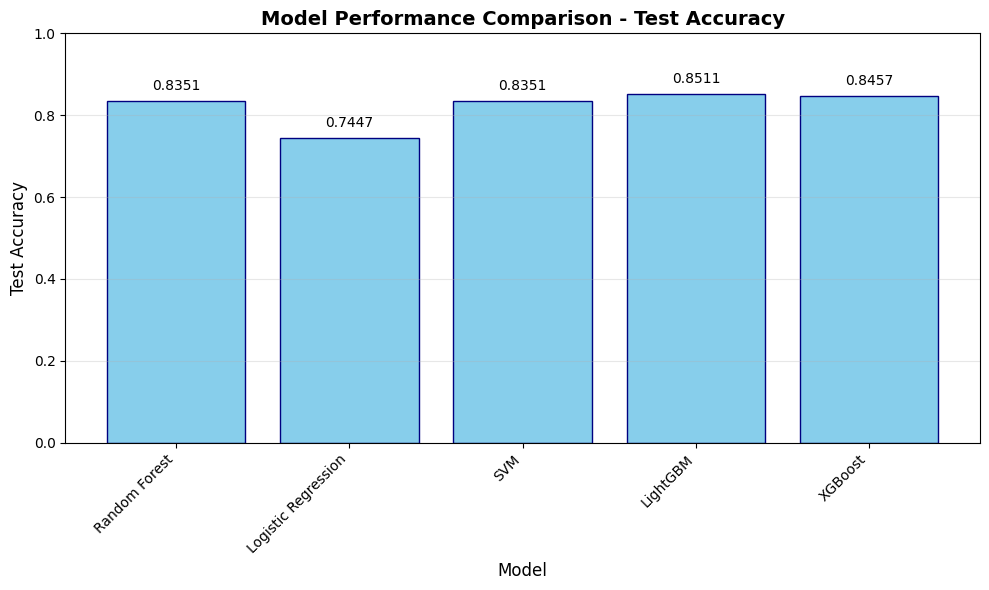

In [160]:
import seaborn as sns

import matplotlib.pyplot as plt

# Create a bar plot comparing all models' test accuracies
plt.figure(figsize=(10, 6))
model_names = list(results.keys())
test_accuracies = [results[name]['test_accuracy'] for name in model_names]

plt.bar(model_names, test_accuracies, color='skyblue', edgecolor='navy')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.title('Model Performance Comparison - Test Accuracy', fontsize=14, fontweight='bold')
plt.ylim([0, 1])
plt.xticks(rotation=45, ha='right')

# Add accuracy values on top of bars
for i, (name, acc) in enumerate(zip(model_names, test_accuracies)):
    plt.text(i, acc + 0.02, f'{acc:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.grid(axis='y', alpha=0.3)
plt.show()

SHAP ANALYSIS - XGBoost Model
SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (188, 102, 4)

Top 30 Most Important Features (by SHAP):
                  Feature  Mean_Abs_SHAP
                      AGE       0.900399
                SLCO1B1_y       0.434968
                    GRADE       0.428592
                  MIR3123       0.289523
                  OR2M7_y       0.228244
SNORD11_ENSG00000238819_1       0.222852
                PIP5K1B_y       0.216867
                  PDS5A_y       0.198039
                 PARD6B_y       0.158191
                  CEP78_y       0.148553
                   IZUMO3       0.143774
                  SF3A1_y       0.138091
                 TBC1D3P5       0.131306
                 ZDHHC7_y       0.121876
                 GALNT7_y       0.115421
                  YWHAH_y       0.111672
                RN7SL592P       0.107858
                   COG4_y       0.100783
                   NEK8_y       0.097738
                   JAK2_y       

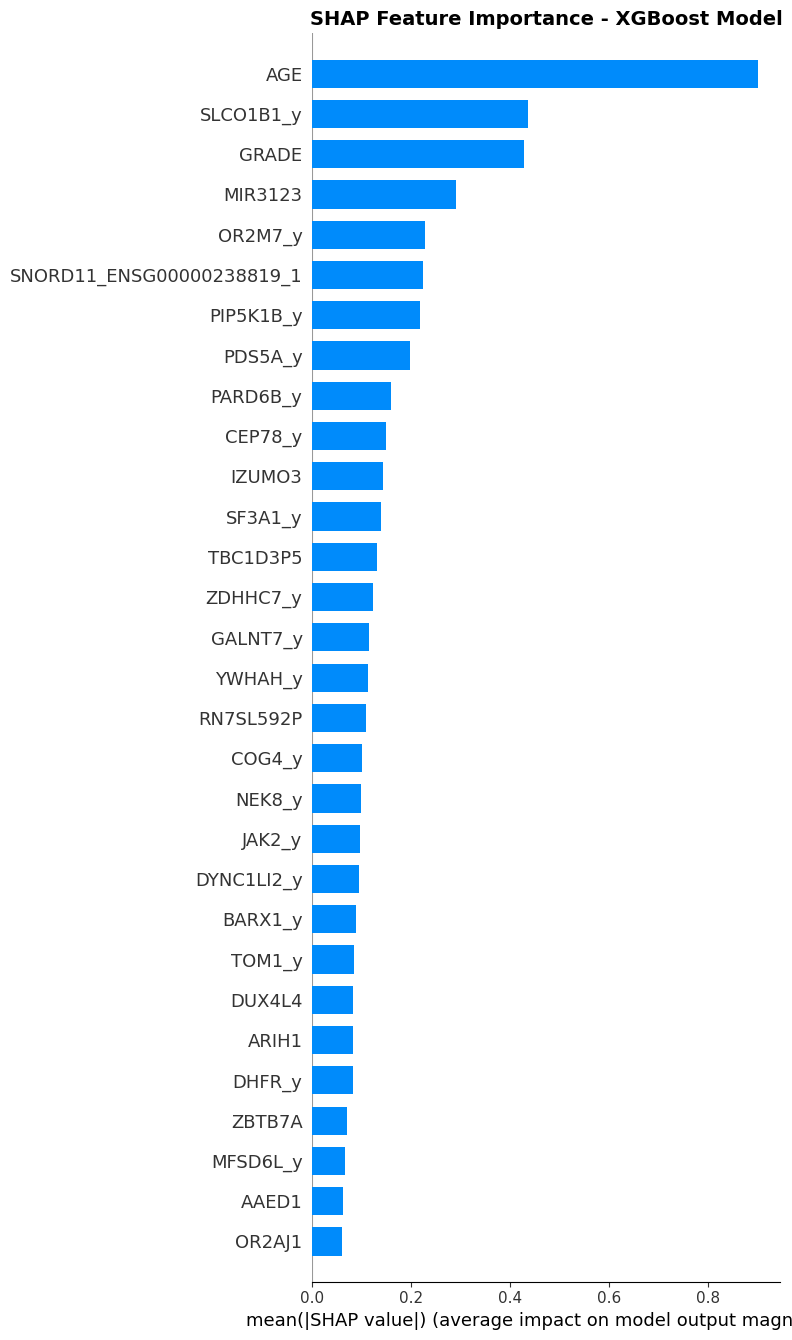

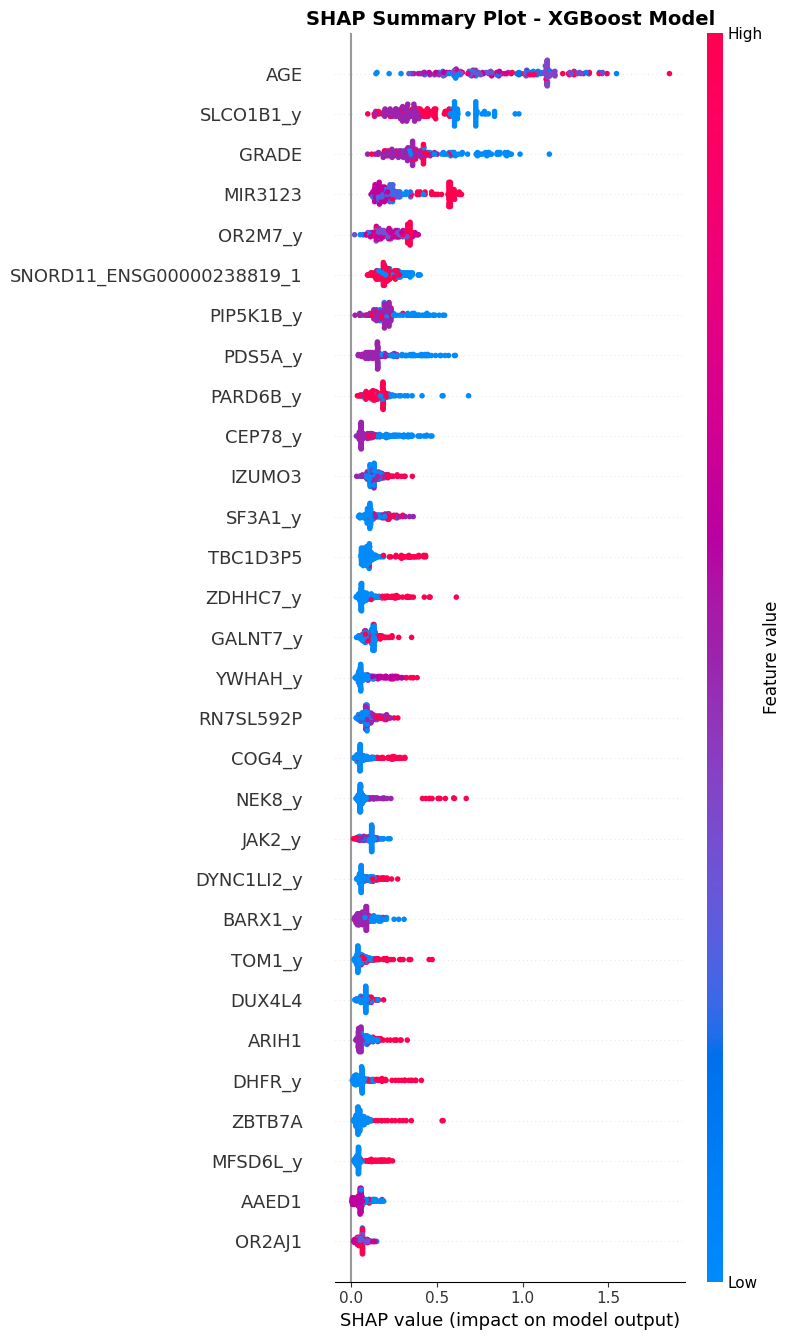

In [161]:
import shap
import numpy as np

import matplotlib.pyplot as plt

# Use the XGBoost model from results
xgb_model_shap = results['XGBoost']['model']

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model_shap)
shap_values = explainer.shap_values(X_test_scaled_final)

# Display SHAP values information
print("="*70)
print("SHAP ANALYSIS - XGBoost Model")
print("="*70)
print(f"SHAP values type: {type(shap_values)}")

# Handle different SHAP value formats
if isinstance(shap_values, list):
    print(f"Number of classes: {len(shap_values)}")
    print(f"SHAP values shape per class: {shap_values[0].shape}")
    
    # Calculate mean absolute SHAP values across all classes and samples
    stacked_shap = np.array(shap_values)
    mean_abs_shap = np.mean(np.abs(stacked_shap), axis=(0, 1))
else:
    print(f"SHAP values shape: {shap_values.shape}")
    if len(shap_values.shape) == 3:
        mean_abs_shap = np.mean(np.abs(shap_values), axis=(0, 2))
    else:
        mean_abs_shap = np.mean(np.abs(shap_values), axis=0)

# Create feature importance dataframe
feature_importance_shap = pd.DataFrame({
    'Feature': X.columns,
    'Mean_Abs_SHAP': mean_abs_shap
}).sort_values('Mean_Abs_SHAP', ascending=False).reset_index(drop=True)

# Display top 30 features
print("\nTop 30 Most Important Features (by SHAP):")
print(feature_importance_shap.head(30).to_string(index=False))

# SHAP Summary Plot (bar)
plt.figure(figsize=(12, 8))
if isinstance(shap_values, list):
    shap_values_plot = np.mean(np.abs(np.array(shap_values)), axis=0)
elif len(shap_values.shape) == 3:
    shap_values_plot = np.mean(np.abs(shap_values), axis=2)
else:
    shap_values_plot = shap_values

shap.summary_plot(shap_values_plot, X_test_scaled_final, 
                  feature_names=X.columns, plot_type="bar", 
                  max_display=30, show=False)
plt.title("SHAP Feature Importance - XGBoost Model", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# SHAP Summary Plot (dot plot)
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values_plot, X_test_scaled_final, 
                  feature_names=X.columns, max_display=30, show=False)
plt.title("SHAP Summary Plot - XGBoost Model", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

SHAP ANALYSIS - LightGBM Model
SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (188, 102, 4)

Top 30 Most Important Features (by SHAP):
                  Feature  Mean_Abs_SHAP
                      AGE       0.922534
                    GRADE       0.482551
                SLCO1B1_y       0.481686
                  MIR3123       0.298723
                  OR2M7_y       0.252279
                PIP5K1B_y       0.226284
                  PDS5A_y       0.216332
SNORD11_ENSG00000238819_1       0.194615
                 PARD6B_y       0.192110
                  CEP78_y       0.153399
                  SF3A1_y       0.147333
                   IZUMO3       0.144267
                 TBC1D3P5       0.127544
                RN7SL592P       0.126719
                 ZDHHC7_y       0.120417
                   NEK8_y       0.117376
                  YWHAH_y       0.116068
               DYNC1LI2_y       0.106730
                   TOM1_y       0.101474
                   DHFR_y      

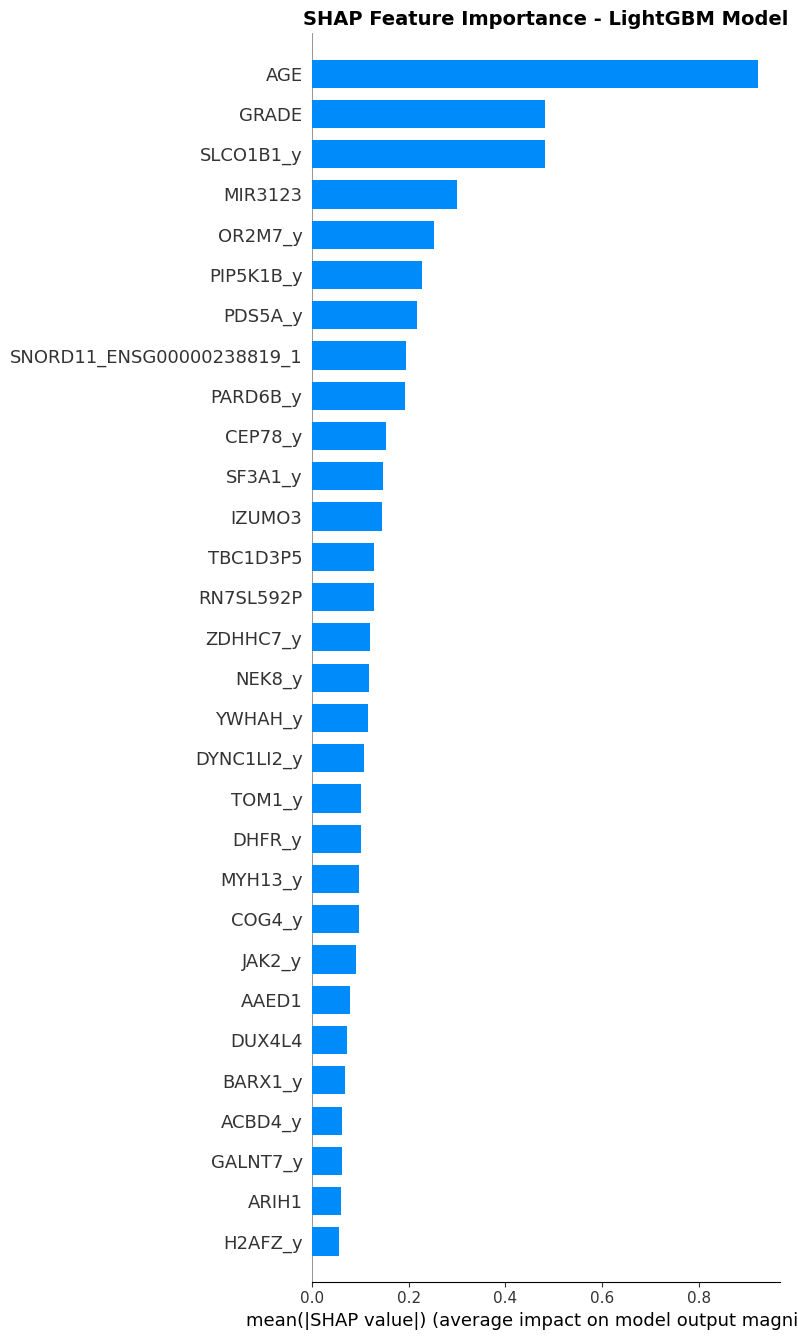

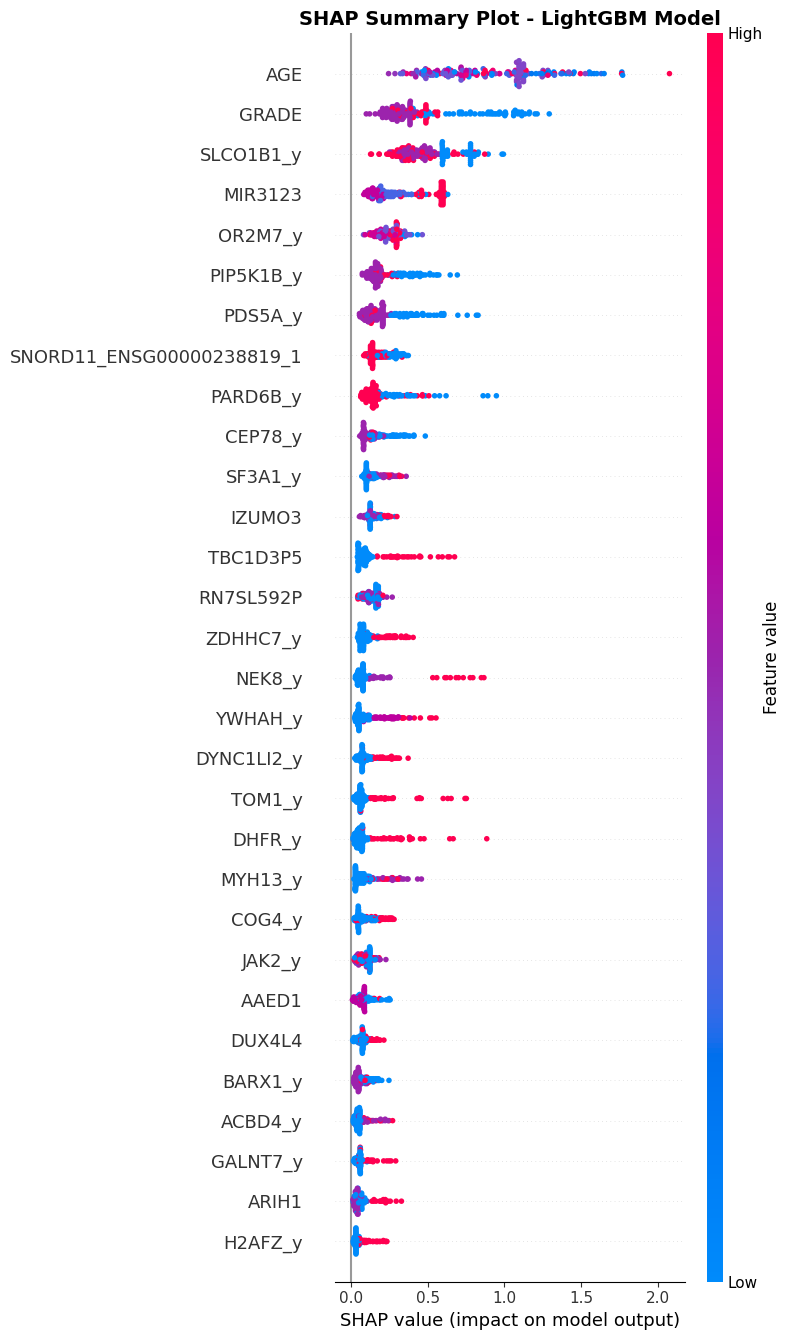


STAGE-WISE SHAP ANALYSIS - LightGBM Model


In [162]:
import shap
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

# Use LightGBM model from results
lgbm_model_shap = results['LightGBM']['model']

# Create SHAP explainer for LightGBM
explainer = shap.TreeExplainer(lgbm_model_shap)
shap_values = explainer.shap_values(X_test_scaled_final)

# Get class names from label encoder
class_names = le.classes_

print("="*70)
print("SHAP ANALYSIS - LightGBM Model")
print("="*70)
print(f"SHAP values type: {type(shap_values)}")

# Handle different SHAP value formats
if isinstance(shap_values, list):
    print(f"Number of classes: {len(shap_values)}")
    print(f"SHAP values shape per class: {shap_values[0].shape}")
    
    # Calculate mean absolute SHAP values across all classes and samples
    stacked_shap = np.array(shap_values)
    mean_abs_shap = np.mean(np.abs(stacked_shap), axis=(0, 1))
else:
    print(f"SHAP values shape: {shap_values.shape}")
    if len(shap_values.shape) == 3:
        mean_abs_shap = np.mean(np.abs(shap_values), axis=(0, 2))
    else:
        mean_abs_shap = np.mean(np.abs(shap_values), axis=0)

# Create feature importance dataframe
feature_importance_shap = pd.DataFrame({
    'Feature': X.columns,
    'Mean_Abs_SHAP': mean_abs_shap
}).sort_values('Mean_Abs_SHAP', ascending=False).reset_index(drop=True)

# Display top 30 features
print("\nTop 30 Most Important Features (by SHAP):")
print(feature_importance_shap.head(30).to_string(index=False))

# SHAP Summary Plot (bar)
plt.figure(figsize=(12, 8))
if isinstance(shap_values, list):
    shap_values_plot = np.mean(np.abs(np.array(shap_values)), axis=0)
elif len(shap_values.shape) == 3:
    shap_values_plot = np.mean(np.abs(shap_values), axis=2)
else:
    shap_values_plot = shap_values

shap.summary_plot(shap_values_plot, X_test_scaled_final, 
                  feature_names=X.columns, plot_type="bar", 
                  max_display=30, show=False)
plt.title("SHAP Feature Importance - LightGBM Model", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# SHAP Summary Plot (dot plot)
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values_plot, X_test_scaled_final, 
                  feature_names=X.columns, max_display=30, show=False)
plt.title("SHAP Summary Plot - LightGBM Model", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Stage-wise SHAP analysis for LightGBM
print("\n" + "="*70)
print("STAGE-WISE SHAP ANALYSIS - LightGBM Model")
print("="*70)

if isinstance(shap_values, list):
    for class_idx, class_name in enumerate(class_names):
        print(f"\n{'='*70}")
        print(f"Clinical Stage: {class_name} (Class {class_idx})")
        print(f"{'='*70}")
        
        # Get SHAP values for this specific class
        class_shap = shap_values[class_idx]
        
        # Calculate mean absolute SHAP values for this class
        mean_abs_shap_class = np.mean(np.abs(class_shap), axis=0)
        
        # Create feature importance dataframe
        feature_importance_class = pd.DataFrame({
            'Feature': X.columns,
            'Mean_Abs_SHAP': mean_abs_shap_class
        }).sort_values('Mean_Abs_SHAP', ascending=False).reset_index(drop=True)
        
        # Display top 30 biomarkers for this stage
        top_30 = feature_importance_class.head(30)
        print(f"\nTop 30 Biomarkers for Clinical Stage {class_name}:")
        print(top_30.to_string(index=False))
        
        # Get indices of top 30 features
        top_30_indices = [X.columns.get_loc(feat) for feat in top_30['Feature']]
        
        # Filter SHAP values and features for top 30
        class_shap_top30 = class_shap[:, top_30_indices]
        X_test_top30 = X_test_scaled_final[:, top_30_indices]
        top_30_names = top_30['Feature'].tolist()
        
        # Create SHAP summary plot (bar) for top 30 features
        plt.figure(figsize=(12, 10))
        shap.summary_plot(
            class_shap_top30,
            X_test_top30,
            feature_names=top_30_names,
            plot_type="bar",
            max_display=30,
            show=False
        )
        plt.title(f"Top 30 Biomarkers - LightGBM - Clinical Stage {class_name}", 
                  fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        # Create SHAP summary plot (dot) for top 30 features
        plt.figure(figsize=(12, 12))
        shap.summary_plot(
            class_shap_top30,
            X_test_top30,
            feature_names=top_30_names,
            max_display=30,
            show=False
        )
        plt.title(f"Top 30 Biomarkers SHAP Summary - LightGBM - Clinical Stage {class_name}", 
                  fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

In [163]:
import shap
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

# Use LightGBM model from results
lgbm_model_stage0 = results['LightGBM']['model']

# Create SHAP explainer
explainer = shap.TreeExplainer(lgbm_model_stage0)
shap_values = explainer.shap_values(X_test_scaled_final)

# Get class names from label encoder
class_names = le.classes_

# Focus on Stage 0 (class index 0)
stage_0_idx = 0
stage_0_name = class_names[stage_0_idx]

print("="*70)
print(f"SHAP ANALYSIS FOR CLINICAL STAGE {stage_0_name} - LightGBM Model")
print("="*70)

# For LightGBM multiclass, shap_values is a list of arrays (one per class)
if isinstance(shap_values, list):
    # Get SHAP values for Stage 0
    stage0_shap = shap_values[stage_0_idx]
    
    # Calculate mean absolute SHAP values for Stage 0
    mean_abs_shap = np.mean(np.abs(stage0_shap), axis=0)
    
    # Create feature importance dataframe
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Mean_Abs_SHAP': mean_abs_shap
    }).sort_values('Mean_Abs_SHAP', ascending=False).reset_index(drop=True)
    
    # Display top 10 biomarkers for Stage 0
    top_10 = feature_importance.head(10)
    print(f"\nTop 10 Biomarkers for Clinical Stage {stage_0_name}:")
    print(top_10.to_string(index=False))
    
    # Get indices of top 10 features
    top_10_indices = [X.columns.get_loc(feat) for feat in top_10['Feature']]
    
    # Filter SHAP values and features for top 10
    stage0_shap_top10 = stage0_shap[:, top_10_indices]
    X_test_top10 = X_test_scaled_final[:, top_10_indices]
    top_10_names = top_10['Feature'].tolist()
    
    # Create SHAP summary plot (bar) for top 10 features
    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        stage0_shap_top10,
        X_test_top10,
        feature_names=top_10_names,
        plot_type="bar",
        max_display=10,
        show=False
    )
    plt.title(f"Top 10 Biomarkers - LightGBM - Clinical Stage {stage_0_name}", 
              fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Create SHAP summary plot (dot) for top 10 features
    plt.figure(figsize=(10, 8))
    shap.summary_plot(
        stage0_shap_top10,
        X_test_top10,
        feature_names=top_10_names,
        max_display=10,
        show=False
    )
    plt.title(f"Top 10 Biomarkers SHAP Summary - LightGBM - Clinical Stage {stage_0_name}", 
              fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

else:
    print("SHAP values format not recognized for multiclass analysis")
    print(f"Type: {type(shap_values)}")
    if hasattr(shap_values, 'shape'):
        print(f"Shape: {shap_values.shape}")

SHAP ANALYSIS FOR CLINICAL STAGE 0 - LightGBM Model
SHAP values format not recognized for multiclass analysis
Type: <class 'numpy.ndarray'>
Shape: (188, 102, 4)


In [180]:
import shap
import numpy as np
import pandas as pd

# Use LightGBM model from results
lgbm_model = results['LightGBM']['model']

# Create SHAP explainer
explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_test_scaled_final)

# Get SHAP values for stage 0 (class index 0)
if isinstance(shap_values, list):
    shap_stage0 = shap_values[0]
else:
    # Handle different SHAP value formats
    if len(shap_values.shape) == 3:
        shap_stage0 = shap_values[:, :, 0]
    else:
        shap_stage0 = shap_values

# Calculate importance
importance = np.mean(np.abs(shap_stage0), axis=0)

biomarker_ranking = pd.DataFrame({
    'biomarker': X.columns,
    'importance': importance
}).sort_values('importance', ascending=False)

print(biomarker_ranking.head(5))


     biomarker  importance
100        AGE    0.799722
1    SLCO1B1_y    0.623847
16     MIR3123    0.558763
101      GRADE    0.319903
25   PIP5K1B_y    0.304224


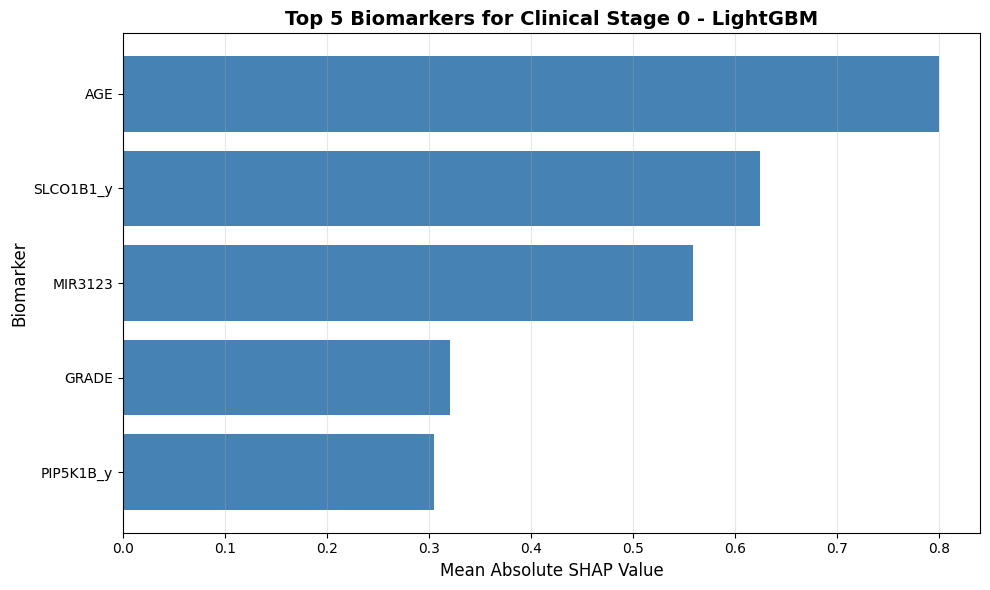

In [183]:
import matplotlib.pyplot as plt

# Visualize top 5 biomarkers for stage 0
plt.figure(figsize=(10, 6))
plt.barh(range(5), biomarker_ranking.head(5)['importance'].values[::-1], color='steelblue')
plt.yticks(range(5), biomarker_ranking.head(5)['biomarker'].values[::-1])
plt.xlabel('Mean Absolute SHAP Value', fontsize=12)
plt.ylabel('Biomarker', fontsize=12)
plt.title('Top 5 Biomarkers for Clinical Stage 0 - LightGBM', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [184]:
import shap
import numpy as np
import pandas as pd

# Use LightGBM model from results
lgbm_model = results['LightGBM']['model']

# Create SHAP explainer
explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_test_scaled_final)

# Get SHAP values for stage 0 (class index 1)
if isinstance(shap_values, list):
    shap_stage1 = shap_values[1]
else:
    # Handle different SHAP value formats
    if len(shap_values.shape) == 3:
        shap_stage0 = shap_values[:, :, 0]
    else:
        shap_stage0 = shap_values

# Calculate importance
importance = np.mean(np.abs(shap_stage0), axis=0)

biomarker_ranking = pd.DataFrame({
    'biomarker': X.columns,
    'importance': importance
}).sort_values('importance', ascending=False)

print(biomarker_ranking.head(5))


     biomarker  importance
100        AGE    0.799722
1    SLCO1B1_y    0.623847
16     MIR3123    0.558763
101      GRADE    0.319903
25   PIP5K1B_y    0.304224


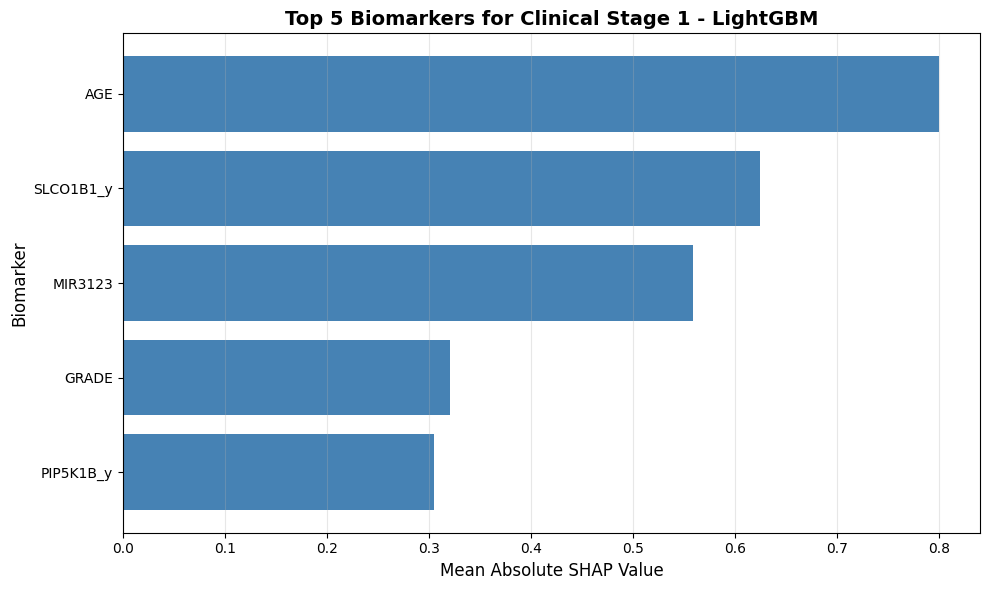

In [186]:
import matplotlib.pyplot as plt

# Visualize top 10 biomarkers for stage 1
plt.figure(figsize=(10, 6))
plt.barh(range(5), biomarker_ranking.head(5)['importance'].values[::-1], color='steelblue')
plt.yticks(range(5), biomarker_ranking.head(5)['biomarker'].values[::-1])
plt.xlabel('Mean Absolute SHAP Value', fontsize=12)
plt.ylabel('Biomarker', fontsize=12)
plt.title('Top 5 Biomarkers for Clinical Stage 1 - LightGBM', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [188]:
# Extract SHAP values for Stage 1 (class index = 1)
stage1_idx = 1

# Use the existing 'shap_values' variable and handle different SHAP formats
if isinstance(shap_values, list):
    shap_stage1 = shap_values[stage1_idx]  # list of (samples, features) per class
elif len(shap_values.shape) == 3:
    shap_stage1 = shap_values[:, :, stage1_idx]   # shape: (samples, features, classes)
else:
    shap_stage1 = shap_values  # binary/regression shape: (samples, features)

# Compute mean absolute SHAP importance for Stage 1
importance_stage1 = np.mean(np.abs(shap_stage1), axis=0)

# Create ranking dataframe
biomarker_ranking_stage1 = pd.DataFrame({
    'biomarker': X.columns,
    'importance': importance_stage1
}).sort_values('importance', ascending=False)

print(biomarker_ranking_stage1.head(5))


     biomarker  importance
100        AGE    1.355634
101      GRADE    1.106530
94     PDS5A_y    0.368243
1    SLCO1B1_y    0.254262
30     CEP78_y    0.253219


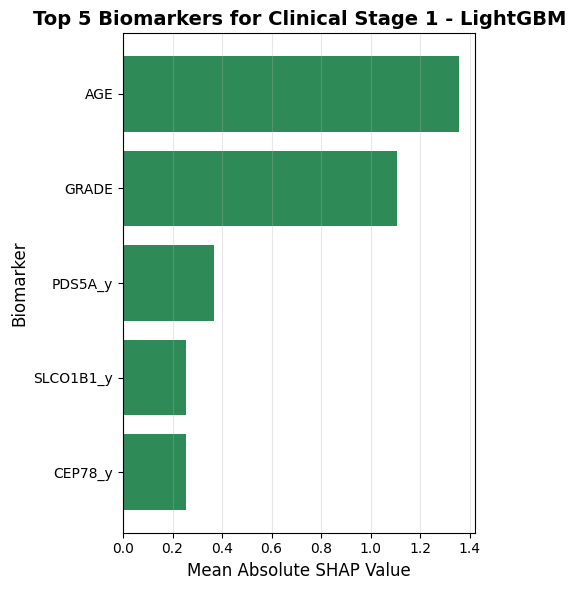

In [189]:
plt.figure(figsize=(5, 6))
plt.barh(range(5), biomarker_ranking_stage1.head(5)['importance'].values[::-1], color='seagreen')
plt.yticks(range(5), biomarker_ranking_stage1.head(5)['biomarker'].values[::-1])
plt.xlabel('Mean Absolute SHAP Value', fontsize=12)
plt.ylabel('Biomarker', fontsize=12)
plt.title('Top 5 Biomarkers for Clinical Stage 1 - LightGBM', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


In [191]:
# Extract SHAP values for Stage 2 (class index = 2)
stage2_idx = 2

# Use the existing 'shap_values' variable and handle different SHAP formats
if isinstance(shap_values, list):
    shap_stage2 = shap_values[stage2_idx]  # list of (samples, features) per class
elif len(shap_values.shape) == 3:
    shap_stage2 = shap_values[:, :, stage2_idx]   # shape: (samples, features, classes)
else:
    shap_stage2 = shap_values  # binary/regression shape: (samples, features)

# Compute mean absolute SHAP importance
importance_stage2 = np.mean(np.abs(shap_stage2), axis=0)

# Ranking dataframe
biomarker_ranking_stage2 = pd.DataFrame({
    'biomarker': X.columns,
    'importance': importance_stage2
}).sort_values('importance', ascending=False)

print("Top 20 biomarkers for Stage 2:")
print(biomarker_ranking_stage2.head(5))


Top 20 biomarkers for Stage 2:
                     biomarker  importance
25                   PIP5K1B_y    0.503859
100                        AGE    0.464414
67                    PARD6B_y    0.370086
94                     PDS5A_y    0.327405
86   SNORD11_ENSG00000238819_1    0.280559


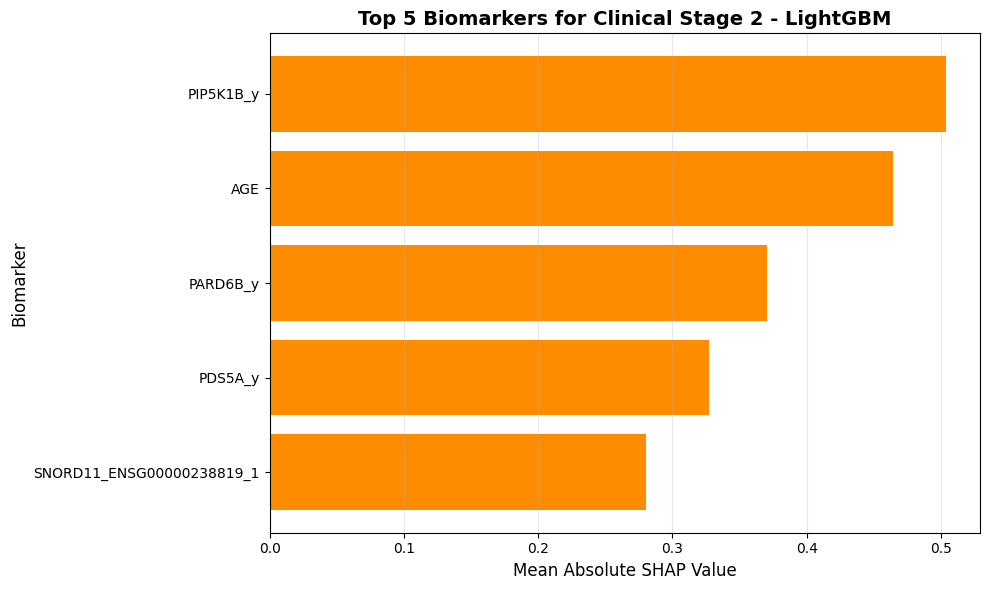

In [192]:
plt.figure(figsize=(10, 6))
plt.barh(range(5), biomarker_ranking_stage2.head(5)['importance'].values[::-1], color='darkorange')
plt.yticks(range(5), biomarker_ranking_stage2.head(5)['biomarker'].values[::-1])
plt.xlabel('Mean Absolute SHAP Value', fontsize=12)
plt.ylabel('Biomarker', fontsize=12)
plt.title('Top 5 Biomarkers for Clinical Stage 2 - LightGBM', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


In [193]:
# Extract SHAP values for Stage 3 (class index = 3)
stage3_idx = 3

# Ensure SHAP values are available
if 'shap_values_raw' not in locals():
    if 'shap_values' in locals():
        shap_values_raw = shap_values
    else:
        explainer = shap.TreeExplainer(results['LightGBM']['model'])
        shap_values_raw = explainer.shap_values(X_test_scaled_final)

# Handle list vs array SHAP formats
if isinstance(shap_values_raw, list):
    shap_stage3 = shap_values_raw[stage3_idx]
elif len(shap_values_raw.shape) == 3:
    shap_stage3 = shap_values_raw[:, :, stage3_idx]
else:
    shap_stage3 = shap_values_raw  # fallback (binary/regression format)

# Compute mean absolute SHAP importance
importance_stage3 = np.mean(np.abs(shap_stage3), axis=0)

# Ranking dataframe
biomarker_ranking_stage3 = pd.DataFrame({
    'biomarker': X.columns,
    'importance': importance_stage3
}).sort_values('importance', ascending=False)

print("Top 20 biomarkers for Stage 3:")
print(biomarker_ranking_stage3.head(5))


Top 20 biomarkers for Stage 3:
                     biomarker  importance
100                        AGE    1.070365
1                    SLCO1B1_y    0.833444
5                      OR2M7_y    0.641112
30                     CEP78_y    0.274705
86   SNORD11_ENSG00000238819_1    0.269474


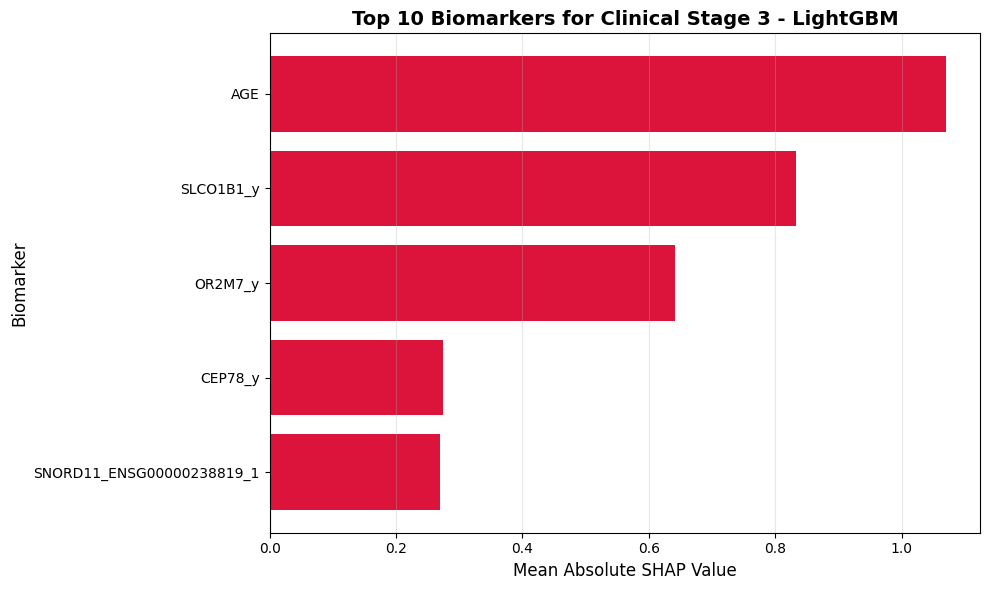

In [178]:
plt.figure(figsize=(10, 6))
plt.barh(range(5), biomarker_ranking_stage3.head(5)['importance'].values[::-1], color='crimson')
plt.yticks(range(5), biomarker_ranking_stage3.head(5)['biomarker'].values[::-1])
plt.xlabel('Mean Absolute SHAP Value', fontsize=12)
plt.ylabel('Biomarker', fontsize=12)
plt.title('Top 10 Biomarkers for Clinical Stage 3 - LightGBM', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
